# A3 — Uso e ociosidade

**Pergunta de negócio:** quais equipamentos são muito usados, quais ficam parados, o que sobra e o que falta?

**Como os números são montados** (view `analise.vw_uso_material`, migração `0009`): para cada tipo de material, duas linhas do tempo construídas do histórico com somas acumuladas (window functions):

- **capacidade:** unidades em circulação (disponíveis ou cauteladas); uma unidade em manutenção, não localizada ou baixada deixa de contar;
- **unidades fora:** +1 quando a unidade é cautelada, −1 quando volta.

Daí saem a **utilização** (horas cauteladas ÷ horas-unidade em circulação), o **pico** de uso simultâneo e as **horas esgotado** (todas as unidades em circulação fora ao mesmo tempo). Período: 12 meses até 31/08/2026. Dados 100% fictícios.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from almox.analise import uso as a3
from almox.banco import engine
from almox.config import carregar_config_banco

pd.set_option("display.width", 160)
uso = a3.ler_uso(engine(carregar_config_banco()))
uso["diagnostico"] = a3.diagnostico(uso)
uso["folga"] = uso.unidades_na_carga - uso.pico_simultaneo
uso[
    [
        "codigo",
        "nome",
        "unidades_na_carga",
        "cautelas",
        "utilizacao",
        "pico_simultaneo",
        "horas_esgotado",
        "unidades_paradas",
        "valor_parado",
        "baixadas_no_periodo",
        "classe_abc",
        "diagnostico",
    ]
]

,codigo,nome,unidades_na_carga,cautelas,utilizacao,pico_simultaneo,horas_esgotado,unidades_paradas,valor_parado,baixadas_no_periodo,classe_abc,diagnostico
0,RAD-0001,Rádio portátil VHF RP-100,34,1978,0.1027,13,0.0,8,20000.0,6,A,ADEQUADO
1,RAD-0002,Rádio portátil VHF digital RP-200,25,1675,0.1150,16,0.0,6,19200.0,5,A,ADEQUADO
2,ILU-0001,Lanterna tática recarregável,7,770,0.2681,8,30.5,0,0.0,8,A,ADEQUADO
3,SIN-0002,Bastão sinalizador luminoso,11,435,0.0748,5,0.0,0,0.0,1,A,ADEQUADO
4,SIN-0001,Cone de sinalização refletivo,28,231,0.0388,8,0.0,1,60.0,2,B,SOBRA
5,FER-0005,Caixa de ferramentas 65 peças,6,133,0.1854,6,24.6,0,0.0,0,B,ADEQUADO
6,INF-0001,Notebook de serviço,5,120,0.2960,6,344.0,0,0.0,1,B,FALTA
7,FER-0001,Furadeira de impacto 800 W,11,110,0.4034,8,244.7,3,1350.0,0,B,FALTA
8,FER-0002,Parafusadeira a bateria 12 V,8,91,0.4953,5,324.6,2,1200.0,0,B,FALTA
9,MED-0001,Multímetro digital,6,86,0.2006,4,93.1,2,500.0,0,B,FALTA


## 1. Curva ABC: poucos tipos concentram o uso

Classe A = os tipos que, somados do mais usado ao menos, formam os primeiros 80% das cautelas.

In [2]:
abc = uso.groupby("classe_abc").agg(tipos=("codigo", "size"), cautelas=("cautelas", "sum"))
abc["% dos tipos"] = (100 * abc.tipos / abc.tipos.sum()).round(1)
abc["% das cautelas"] = (100 * abc.cautelas / abc.cautelas.sum()).round(1)
abc.reindex(["A", "B", "C", "SEM USO"])

,tipos,cautelas,% dos tipos,% das cautelas
classe_abc,,,,
A,4,4858,16.0,81.0
B,7,851,28.0,14.2
C,8,285,32.0,4.8
SEM USO,6,0,24.0,0.0


## 2. O que sobra

Valor parado = unidades na carga que não saíram nenhuma vez em 12 meses × custo unitário (fictício).

In [3]:
COR = {
    "serie": "#2a78d6",
    "contexto": "#8f8e89",
    "fundo": "#fcfcfb",
    "texto": "#0b0b0b",
    "texto2": "#52514e",
    "grade": "#e4e3df",
}
plt.rcParams.update(
    {
        "figure.facecolor": COR["fundo"],
        "axes.facecolor": COR["fundo"],
        "axes.edgecolor": COR["grade"],
        "axes.labelcolor": COR["texto2"],
        "xtick.color": COR["texto2"],
        "ytick.color": COR["texto"],
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": False,
        "font.size": 10,
    }
)


def barras(serie, titulo, rotulo):
    _fig, ax = plt.subplots(figsize=(8, 0.42 * len(serie) + 0.9))
    b = ax.barh(serie.index, serie.values, height=0.7, color=COR["serie"])
    ax.bar_label(
        b, labels=[rotulo(v) for v in serie.values], padding=3, color=COR["texto"], fontsize=9
    )
    ax.set_title(titulo, loc="left", color=COR["texto"], fontsize=11)
    ax.set_xlim(0, serie.max() * 1.18)
    ax.xaxis.grid(True, color=COR["grade"], linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(axis="y", length=0)
    plt.tight_layout()
    plt.show()

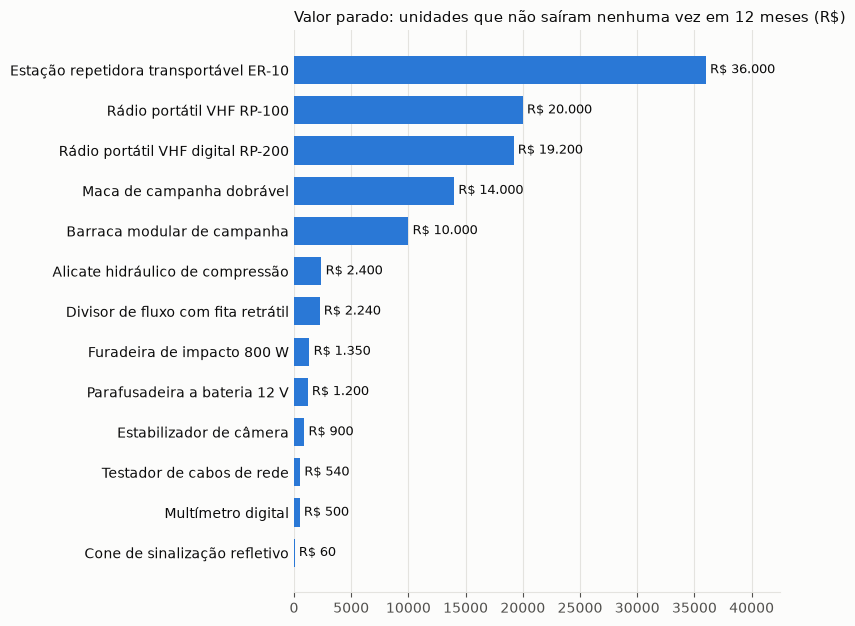

6 tipos sem nenhuma cautela no ano: R$ 63.840 parados.


In [4]:
parado = uso.set_index("nome").valor_parado.sort_values()
parado = parado[parado > 0]
barras(
    parado,
    "Valor parado: unidades que não saíram nenhuma vez em 12 meses (R$)",
    lambda v: f"R$ {v:,.0f}".replace(",", "."),
)
sem_uso = uso[uso.cautelas == 0]
print(
    f"{len(sem_uso)} tipos sem nenhuma cautela no ano: R$ "
    f"{sem_uso.valor_parado.sum():,.0f} parados.".replace(",", ".")
)

In [5]:
radios = uso[uso.subcategoria == "Rádios portáteis"]
radios[
    ["nome", "unidades_na_carga", "pico_simultaneo", "folga", "unidades_paradas", "valor_parado"]
]

,nome,unidades_na_carga,pico_simultaneo,folga,unidades_paradas,valor_parado
0,Rádio portátil VHF RP-100,34,13,21,8,20000.0
1,Rádio portátil VHF digital RP-200,25,16,9,6,19200.0


## 3. O que falta

Horas esgotado = tempo em que todas as unidades em circulação estavam fora.

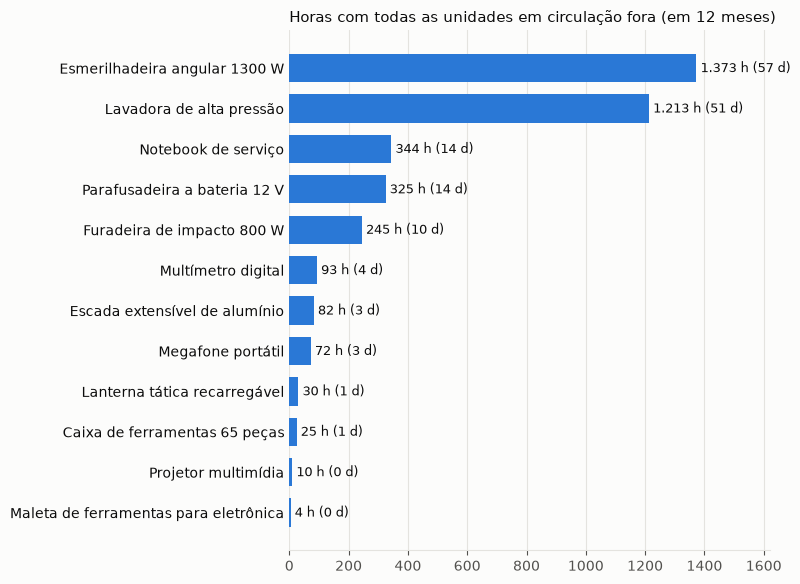

In [6]:
esgotado = uso.set_index("nome").horas_esgotado.sort_values()
esgotado = esgotado[esgotado > 0]
barras(
    esgotado,
    "Horas com todas as unidades em circulação fora (em 12 meses)",
    lambda h: f"{h:,.0f} h ({h / 24:.0f} d)".replace(",", "."),
)

## 4. O que se desgasta

In [7]:
desgaste = uso[uso.baixadas_no_periodo > 0][
    ["nome", "cautelas", "baixadas_no_periodo", "unidades_na_carga"]
]
desgaste.assign(unidades_no_inicio=desgaste.unidades_na_carga + desgaste.baixadas_no_periodo)

,nome,cautelas,baixadas_no_periodo,unidades_na_carga,unidades_no_inicio
0,Rádio portátil VHF RP-100,1978,6,34,40
1,Rádio portátil VHF digital RP-200,1675,5,25,30
2,Lanterna tática recarregável,770,8,7,15
3,Bastão sinalizador luminoso,435,1,11,12
4,Cone de sinalização refletivo,231,2,28,30
6,Notebook de serviço,120,1,5,6
18,Lavadora de alta pressão,17,2,0,2


## Insights

1. **Uso muito concentrado.** 4 tipos (16% dos 25 cauteláveis) respondem por 81% das cautelas: os dois rádios portáteis, a lanterna e o bastão sinalizador. Seis tipos não tiveram nenhuma cautela no ano.
2. **R$ 66 mil parados em material que não sai**, R$ 64 mil só nos seis tipos sem uso: as duas estações repetidoras (R$ 36 mil), 20 macas (R$ 14 mil) e 4 barracas (R$ 10 mil). Há também folga nos rádios: no pico, 13 de 34 RP-100 e 16 de 25 RP-200 estavam fora. As 14 unidades que nunca saíram somam R$ 39 mil.
3. **Falta onde o uso é longo.** A esmerilhadeira passou 1.373 horas (57 dias) com as 3 unidades fora; a lavadora, 1.213 h; notebook, parafusadeira e furadeira, de 245 a 344 h. É o mesmo grupo das cautelas longas da Manutenção (A2). Megafone e escada esgotam só nos dias de solenidade (72 e 82 h no ano).
4. **Recomendação: remanejar da sobra para a falta.** O valor de uma estação repetidora sem uso (R$ 18 mil fictícios) compraria mais de 40 esmerilhadeiras (R$ 380). Antes de comprar, vale combinar com a A2: um prazo de cautela próprio da Manutenção reduz o tempo fora e, portanto, a falta.
5. **Desgaste na lanterna.** 8 das 15 lanternas foram baixadas no ano (uso diário, item barato). É candidata a compra periódica planejada, e não a reposição de emergência.